IMPLÉMENTATION FROM SCRATCH

Porte AND:
  Poids: [0.2 0.2], Biais: 0.2000
  Prédictions: [0 0 0 1]  |  Attendu: [0 0 0 1]
  Précision: 100.0%

Porte OR:
  Poids: [0.2 0.2], Biais: 0.3000
  Prédictions: [0 1 1 1]  |  Attendu: [0 1 1 1]
  Précision: 100.0%

IMPLÉMENTATION SCIKIT-LEARN

Porte AND:
  Poids: [2. 2.], Biais: -3.0000
  Prédictions: [0 0 0 1]  |  Attendu: [0 0 0 1]
  Précision: 100.0%

Porte OR:
  Poids: [2. 2.], Biais: -1.0000
  Prédictions: [0 1 1 1]  |  Attendu: [0 1 1 1]
  Précision: 100.0%

IMPLÉMENTATION KERAS

Porte AND:
  Prédictions: [0 0 0 1]  |  Attendu: [0 0 0 1]
  Précision: 100.0%

Porte OR:
  Prédictions: [0 1 1 1]  |  Attendu: [0 1 1 1]
  Précision: 100.0%


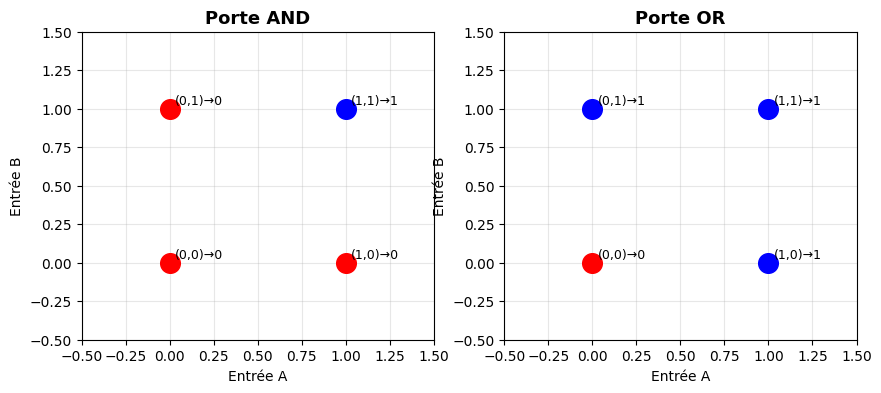

In [2]:
# TP1 - Exercice1:Classification des portes logiques AND et OR avec le Perceptron
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras

# 1. Création des ensembles de données
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y_and = np.array([0, 0, 0, 1])  # AND
y_or  = np.array([0, 1, 1, 1])  # OR

# IMPLÉMENTATION 1 : FROM SCRATCH

class PerceptronScratch:
    def __init__(self, lr=0.1, n_iter=100):
        self.lr = lr
        self.n_iter = n_iter

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0
        self.errors_ = []
        for _ in range(self.n_iter):
            err = 0
            for xi, yi in zip(X, y):
                pred = self.predict_single(xi)
                update = self.lr * (yi - pred)
                self.w += update * xi
                self.b += update
                err += int(update != 0)
            self.errors_.append(err)
        return self

    def predict_single(self, x):
        return 1 if np.dot(x, self.w) + self.b >= 0.5 else 0

    def predict(self, X):
        return np.array([self.predict_single(xi) for xi in X])

    def accuracy(self, X, y):
        return np.mean(self.predict(X) == y)

print("=" * 60)
print("IMPLÉMENTATION FROM SCRATCH")
print("=" * 60)

for gate_name, y_gate in [("AND", y_and), ("OR", y_or)]:
    p = PerceptronScratch(lr=0.1, n_iter=100)
    p.fit(X, y_gate)
    preds = p.predict(X)
    acc = p.accuracy(X, y_gate)
    print(f"\nPorte {gate_name}:")
    print(f"  Poids: {p.w}, Biais: {p.b:.4f}")
    print(f"  Prédictions: {preds}  |  Attendu: {y_gate}")
    print(f"  Précision: {acc * 100:.1f}%")

# IMPLÉMENTATION 2 : SCIKIT-LEARN

print("\n" + "=" * 60)
print("IMPLÉMENTATION SCIKIT-LEARN")
print("=" * 60)

for gate_name, y_gate in [("AND", y_and), ("OR", y_or)]:
    clf = SklearnPerceptron(max_iter=1000, random_state=42)
    clf.fit(X, y_gate)
    preds = clf.predict(X)
    acc = accuracy_score(y_gate, preds)
    print(f"\nPorte {gate_name}:")
    print(f"  Poids: {clf.coef_[0]}, Biais: {clf.intercept_[0]:.4f}")
    print(f"  Prédictions: {preds}  |  Attendu: {y_gate}")
    print(f"  Précision: {acc * 100:.1f}%")

# IMPLÉMENTATION 3 : KERAS

print("\n" + "=" * 60)
print("IMPLÉMENTATION KERAS")
print("=" * 60)

for gate_name, y_gate in [("AND", y_and), ("OR", y_or)]:
    model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(1, activation='sigmoid')
])
    model.compile(optimizer=keras.optimizers.SGD(learning_rate=0.1),
                  loss='binary_crossentropy', metrics=['accuracy'])
    model.fit(X, y_gate, epochs=500, verbose=0)
    loss, acc = model.evaluate(X, y_gate, verbose=0)
    preds = (model.predict(X, verbose=0) >= 0.5).astype(int).flatten()
    print(f"\nPorte {gate_name}:")
    print(f"  Prédictions: {preds}  |  Attendu: {y_gate}")
    print(f"  Précision: {acc * 100:.1f}%")

# VISUALISATION

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
titles = ["Porte AND", "Porte OR"]
labels = [y_and, y_or]
colors_map = {0: 'red', 1: 'blue'}

for ax, title, y_gate in zip(axes, titles, labels):
    for xi, yi in zip(X, y_gate):
        ax.scatter(xi[0], xi[1], c=colors_map[yi], s=200, zorder=3,
                   label=str(yi))
        ax.annotate(f"({xi[0]},{xi[1]})→{yi}", (xi[0]+0.03, xi[1]+0.03), fontsize=9)
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_xlabel("Entrée A")
    ax.set_ylabel("Entrée B")
    ax.grid(True, alpha=0.3)

plt.show()


IMPLÉMENTATION FROM SCRATCH
Précision sur test: 100.00%
              precision    recall  f1-score   support

      Autres       1.00      1.00      1.00        30
 Iris Setosa       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

IMPLÉMENTATION SCIKIT-LEARN
Précision sur test: 100.00%
              precision    recall  f1-score   support

      Autres       1.00      1.00      1.00        30
 Iris Setosa       1.00      1.00      1.00        15

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45

IMPLÉMENTATION KERAS
Précision sur test: 100.00%
              precision    recall  f1-score   support

      Autres       1.00      1.00      1.00        30
 Iris Setosa       1.00      1.00      1.00        15

    accuracy         

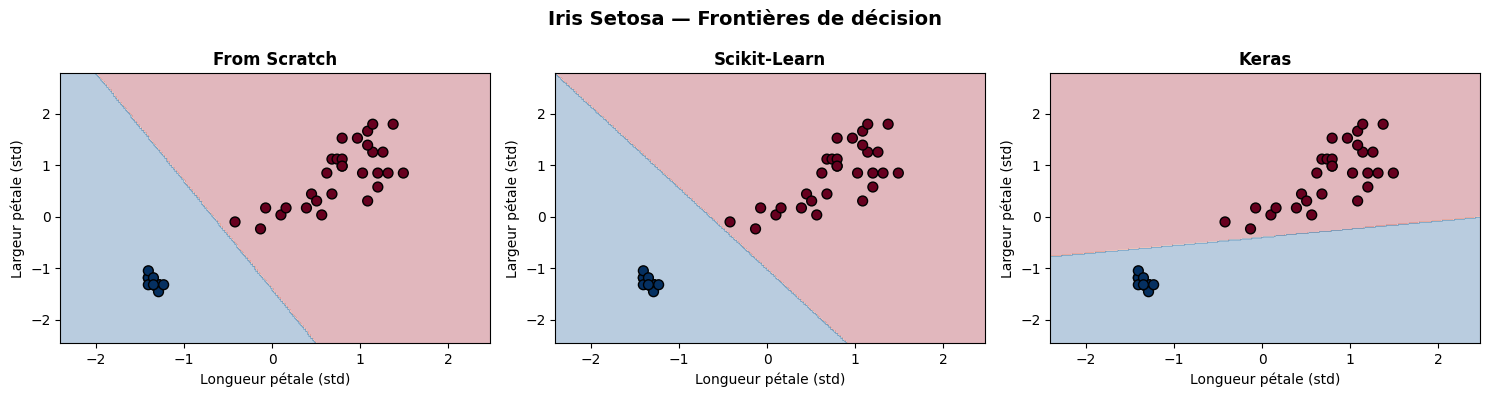


Résumé précisions → Scratch: 100.0% | Sklearn: 100.0% | Keras: 100.0%


In [4]:
# TP1 - Exercice 2 : Classification binaire sur les données Iris Setosa
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score, classification_report
import tensorflow as tf
from tensorflow import keras

# 1. Chargement et préparation des données

iris = load_iris()
X = iris.data[:, 2:4]   # longueur et largeur des pétales
y = (iris.target == 0).astype(int)  # 1 = Setosa, 0 = Autres

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# IMPLÉMENTATION 1 : FROM SCRATCH

class PerceptronScratch:
    def __init__(self, lr=0.01, n_iter=200):
        self.lr = lr
        self.n_iter = n_iter

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0.0
        self.errors_ = []
        for _ in range(self.n_iter):
            err = 0
            for xi, yi in zip(X, y):
                yhat = self._step(np.dot(xi, self.w) + self.b)
                delta = self.lr * (yi - yhat)
                self.w += delta * xi
                self.b += delta
                err += int(delta != 0)
            self.errors_.append(err)
        return self

    def _step(self, z): return 1 if z >= 0 else 0

    def predict(self, X):
        return np.array([self._step(np.dot(xi, self.w) + self.b) for xi in X])

print("=" * 60)
print("IMPLÉMENTATION FROM SCRATCH")
print("=" * 60)
p = PerceptronScratch(lr=0.01, n_iter=200)
p.fit(X_train_sc, y_train)
preds_scratch = p.predict(X_test_sc)
acc_scratch = accuracy_score(y_test, preds_scratch)
print(f"Précision sur test: {acc_scratch * 100:.2f}%")
print(classification_report(y_test, preds_scratch,
      target_names=['Autres', 'Iris Setosa']))

# IMPLÉMENTATION 2 : SCIKIT-LEARN

print("=" * 60)
print("IMPLÉMENTATION SCIKIT-LEARN")
print("=" * 60)
clf = SklearnPerceptron(max_iter=1000, random_state=42)
clf.fit(X_train_sc, y_train)
preds_sk = clf.predict(X_test_sc)
acc_sk = accuracy_score(y_test, preds_sk)
print(f"Précision sur test: {acc_sk * 100:.2f}%")
print(classification_report(y_test, preds_sk,
      target_names=['Autres', 'Iris Setosa']))

# IMPLÉMENTATION 3 : KERAS

print("=" * 60)
print("IMPLÉMENTATION KERAS")
print("=" * 60)
# NOUVEAU (propre, sans warning)
model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train_sc, y_train, epochs=100, batch_size=8, verbose=0)
loss, acc_keras = model.evaluate(X_test_sc, y_test, verbose=0)
preds_keras = (model.predict(X_test_sc, verbose=0) >= 0.5).astype(int).flatten()
print(f"Précision sur test: {acc_keras * 100:.2f}%")
print(classification_report(y_test, preds_keras,
      target_names=['Autres', 'Iris Setosa']))

# VISUALISATION - Frontières de décision

def plot_decision_boundary(ax, clf_func, X, y, title):
    h = 0.02
    x_min, x_max = X[:, 0].min()-1, X[:, 0].max()+1
    y_min, y_max = X[:, 1].min()-1, X[:, 1].max()+1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    Z = clf_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdBu)
    scatter = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdBu,
                         edgecolors='k', s=50)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel("Longueur pétale (std)")
    ax.set_ylabel("Largeur pétale (std)")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_decision_boundary(axes[0], p.predict, X_test_sc, y_test, "From Scratch")
plot_decision_boundary(axes[1], clf.predict, X_test_sc, y_test, "Scikit-Learn")
plot_decision_boundary(axes[2],
    lambda X: (model.predict(X, verbose=0) >= 0.5).astype(int).flatten(),
    X_test_sc, y_test, "Keras")
plt.suptitle("Iris Setosa — Frontières de décision", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print(f"\nRésumé précisions → Scratch: {acc_scratch*100:.1f}% | Sklearn: {acc_sk*100:.1f}% | Keras: {acc_keras*100:.1f}%")

IMPLÉMENTATION FROM SCRATCH
MSE (test) : 0.1954
Poids appris : w=2.0028, b=0.9739  (attendu : w≈2, b≈1)

IMPLÉMENTATION SCIKIT-LEARN (SGDRegressor)
MSE (test) : 0.1871
Poids appris : w=2.0402, b=0.9900

IMPLÉMENTATION KERAS
MSE (test) : 0.1975
Poids appris : w=1.9987, b=0.9722


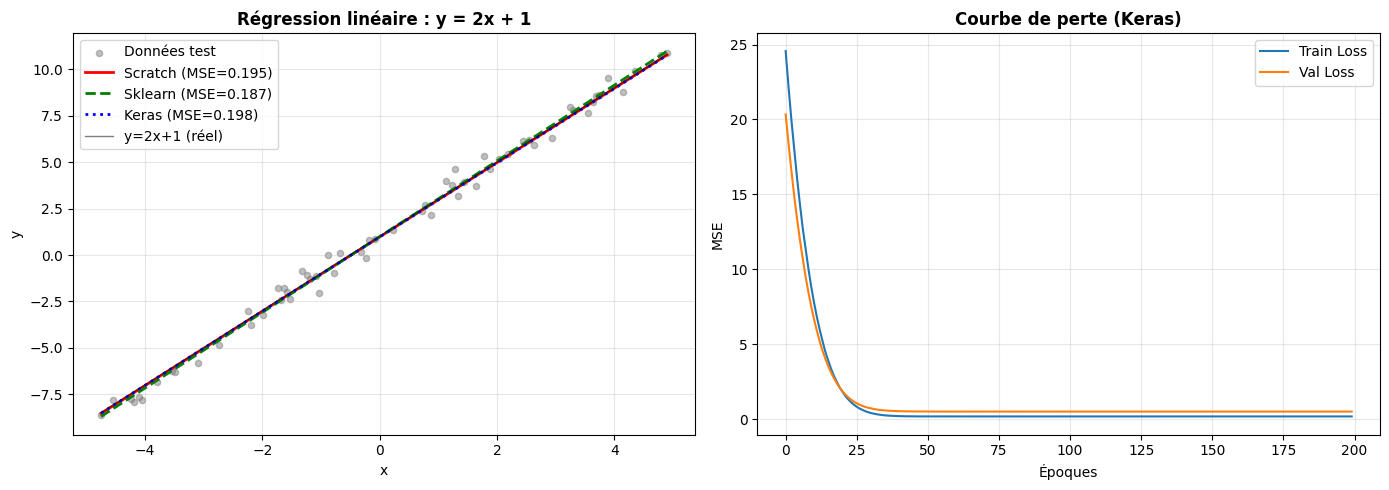


Résumé MSE → Scratch: 0.1954 | Sklearn: 0.1871 | Keras: 0.1975


In [9]:
# TP1 - Exercice 3 : Régression linéaire avec le Perceptron

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDRegressor
from sklearn.metrics import mean_squared_error
import tensorflow as tf
from tensorflow import keras
import warnings
warnings.filterwarnings('ignore')

# 1. Création du jeu de données : y = 2x + 1 + bruit

np.random.seed(42)
N = 200
x = np.linspace(-5, 5, N)
y = 2 * x + 1 + np.random.normal(0, 0.5, N)

X = x.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# IMPLÉMENTATION 1 : FROM SCRATCH (descente de gradient)

class PerceptronRegression:
    """Perceptron linéaire (activation identité) entraîné par descente de gradient."""
    def __init__(self, lr=0.01, n_iter=500):
        self.lr = lr
        self.n_iter = n_iter

    def fit(self, X, y):
        n, m = X.shape
        self.w = np.zeros(m)
        self.b = 0.0
        self.mse_history = []
        for _ in range(self.n_iter):
            y_hat = X @ self.w + self.b
            err = y_hat - y
            self.w -= self.lr * (2 / n) * (X.T @ err)
            self.b -= self.lr * (2 / n) * err.sum()
            self.mse_history.append(np.mean(err**2))
        return self

    def predict(self, X):
        return X @ self.w + self.b

print("=" * 60)
print("IMPLÉMENTATION FROM SCRATCH")
print("=" * 60)
p = PerceptronRegression(lr=0.01, n_iter=500)
p.fit(X_train, y_train)
y_pred_scratch = p.predict(X_test)
mse_scratch = mean_squared_error(y_test, y_pred_scratch)
print(f"MSE (test) : {mse_scratch:.4f}")
print(f"Poids appris : w={p.w[0]:.4f}, b={p.b:.4f}  (attendu : w≈2, b≈1)")

# IMPLÉMENTATION 2 : SCIKIT-LEARN (SGDRegressor)

print("\n" + "=" * 60)
print("IMPLÉMENTATION SCIKIT-LEARN (SGDRegressor)")
print("=" * 60)
clf_sk = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01, random_state=42)
clf_sk.fit(X_train, y_train)
y_pred_sk = clf_sk.predict(X_test)
mse_sk = mean_squared_error(y_test, y_pred_sk)
print(f"MSE (test) : {mse_sk:.4f}")
print(f"Poids appris : w={clf_sk.coef_[0]:.4f}, b={clf_sk.intercept_[0]:.4f}")

# IMPLÉMENTATION 3 : KERAS

print("\n" + "=" * 60)
print("IMPLÉMENTATION KERAS")
print("=" * 60)
model = keras.Sequential([
    keras.layers.Dense(1, activation='linear', input_shape=(1,))
])
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.01), loss='mse')
history = model.fit(X_train, y_train, epochs=200, batch_size=16,
                    validation_split=0.1, verbose=0)
y_pred_keras = model.predict(X_test, verbose=0).flatten()
mse_keras = mean_squared_error(y_test, y_pred_keras)
w_keras = model.layers[0].get_weights()
print(f"MSE (test) : {mse_keras:.4f}")
print(f"Poids appris : w={w_keras[0][0][0]:.4f}, b={w_keras[1][0]:.4f}")


# VISUALISATION

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Droites de régression
axes[0].scatter(X_test, y_test, alpha=0.5, label="Données test", color='gray', s=20)
x_line = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
axes[0].plot(x_line, p.predict(x_line), 'r-', lw=2, label=f"Scratch (MSE={mse_scratch:.3f})")
axes[0].plot(x_line, clf_sk.predict(x_line), 'g--', lw=2, label=f"Sklearn (MSE={mse_sk:.3f})")
axes[0].plot(x_line, model.predict(x_line, verbose=0), 'b:', lw=2, label=f"Keras (MSE={mse_keras:.3f})")
axes[0].plot(x_line, 2*x_line+1, 'k-', lw=1, alpha=0.5, label="y=2x+1 (réel)")
axes[0].set_title("Régression linéaire : y = 2x + 1", fontweight='bold')
axes[0].legend()
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].grid(True, alpha=0.3)

# Graphique 2 : Courbe de loss Keras
axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Val Loss')
axes[1].set_title("Courbe de perte (Keras)", fontweight='bold')
axes[1].set_xlabel("Époques"); axes[1].set_ylabel("MSE")
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print(f"\nRésumé MSE → Scratch: {mse_scratch:.4f} | Sklearn: {mse_sk:.4f} | Keras: {mse_keras:.4f}")

Chargement MNIST...
Train: (10000, 784), Test: (2000, 784)

FROM SCRATCH (OvA multi-classe)
Précision test : 84.55%

SCIKIT-LEARN
Précision test : 82.65%

KERAS
Epoch 1/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6979 - loss: 1.1864 - val_accuracy: 0.8480 - val_loss: 0.6616
Epoch 2/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8637 - loss: 0.5784 - val_accuracy: 0.8870 - val_loss: 0.4775
Epoch 3/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8879 - loss: 0.4553 - val_accuracy: 0.9010 - val_loss: 0.4147
Epoch 4/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8991 - loss: 0.3977 - val_accuracy: 0.9060 - val_loss: 0.3765
Epoch 5/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9059 - loss: 0.3636 - val_accuracy: 0.9060 - val_loss: 0.3560
Epoch 6/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9118 - loss: 0.3383 - val_accuracy: 0.9110 - val_loss: 0.3393
Epoch 7/10
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9158 

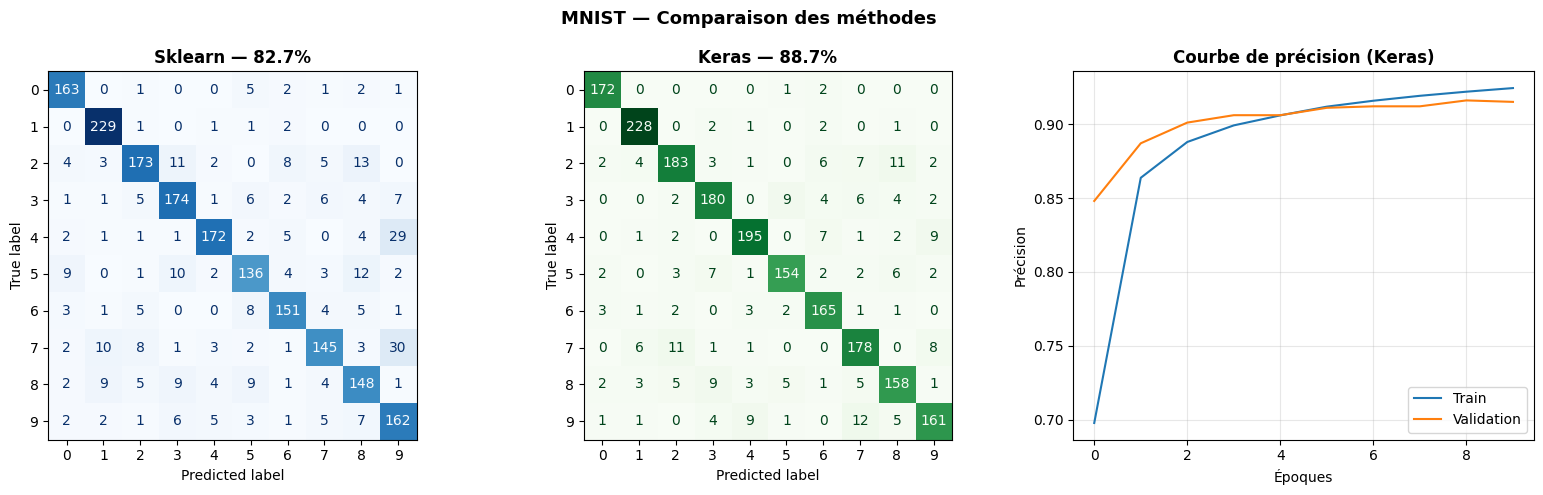


Résumé précisions → Scratch: 84.5% | Sklearn: 82.7% | Keras: 88.7%


In [12]:

# TP1 - Exercice 4 : Application du Perceptron sur MNIST

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, confusion_matrix
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow import keras

# 1. Chargement et préparation MNIST (sous-ensemble)

print("Chargement MNIST...")
mnist = fetch_openml('mnist_784', version=1, as_frame=False, parser='auto')
X_full = mnist.data.astype('float32')
y_full = mnist.target.astype('int')

# Sous-ensemble : 10 000 train, 2 000 test
X_train, X_test = X_full[:10000], X_full[60000:62000]
y_train, y_test = y_full[:10000], y_full[60000:62000]

# Normalisation
X_train_n = X_train / 255.0
X_test_n  = X_test  / 255.0

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_n)
X_test_sc  = scaler.transform(X_test_n)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# IMPLÉMENTATION 1 : FROM SCRATCH (multi-classe OvA)

class PerceptronScratch:
    """Perceptron multi-classe : One-vs-All."""
    def __init__(self, lr=0.01, n_iter=20):
        self.lr = lr
        self.n_iter = n_iter

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        n_feat = X.shape[1]
        self.W = np.zeros((len(self.classes_), n_feat))
        self.b = np.zeros(len(self.classes_))
        for epoch in range(self.n_iter):
            for xi, yi in zip(X, y):
                scores = self.W @ xi + self.b
                pred   = np.argmax(scores)
                if pred != yi:
                    self.W[yi]   += self.lr * xi
                    self.b[yi]   += self.lr
                    self.W[pred] -= self.lr * xi
                    self.b[pred] -= self.lr
        return self

    def predict(self, X):
        scores = X @ self.W.T + self.b
        return np.argmax(scores, axis=1)

print("\n" + "=" * 60)
print("FROM SCRATCH (OvA multi-classe)")
print("=" * 60)
p = PerceptronScratch(lr=0.005, n_iter=15)
p.fit(X_train_sc, y_train)
preds_scratch = p.predict(X_test_sc)
acc_scratch = accuracy_score(y_test, preds_scratch)
print(f"Précision test : {acc_scratch * 100:.2f}%")

# IMPLÉMENTATION 2 : SCIKIT-LEARN

print("\n" + "=" * 60)
print("SCIKIT-LEARN")
print("=" * 60)
clf = SklearnPerceptron(max_iter=50, random_state=42, n_jobs=-1)
clf.fit(X_train_sc, y_train)
preds_sk = clf.predict(X_test_sc)
acc_sk = accuracy_score(y_test, preds_sk)
print(f"Précision test : {acc_sk * 100:.2f}%")

# IMPLÉMENTATION 3 : KERAS

print("\n" + "=" * 60)
print("KERAS")
print("=" * 60)
y_train_cat = keras.utils.to_categorical(y_train, 10)
y_test_cat  = keras.utils.to_categorical(y_test, 10)

model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(10, activation='softmax')
])
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
history = model.fit(X_train_n, y_train_cat, epochs=10, batch_size=64,
                    validation_split=0.1, verbose=1)
loss, acc_keras = model.evaluate(X_test_n, y_test_cat, verbose=0)
preds_keras = np.argmax(model.predict(X_test_n, verbose=0), axis=1)
print(f"Précision test : {acc_keras * 100:.2f}%")

# VISUALISATION

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Matrice de confusion sklearn
cm = confusion_matrix(y_test, preds_sk)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f"Sklearn — {acc_sk*100:.1f}%", fontweight='bold')

# Matrice de confusion Keras
cm_k = confusion_matrix(y_test, preds_keras)
disp_k = ConfusionMatrixDisplay(confusion_matrix=cm_k)
disp_k.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f"Keras — {acc_keras*100:.1f}%", fontweight='bold')

# Courbe de précision Keras
axes[2].plot(history.history['accuracy'], label='Train')
axes[2].plot(history.history['val_accuracy'], label='Validation')
axes[2].set_title("Courbe de précision (Keras)", fontweight='bold')
axes[2].set_xlabel("Époques"); axes[2].set_ylabel("Précision")
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.suptitle("MNIST — Comparaison des méthodes", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nRésumé précisions → Scratch: {acc_scratch*100:.1f}% | Sklearn: {acc_sk*100:.1f}% | Keras: {acc_keras*100:.1f}%")


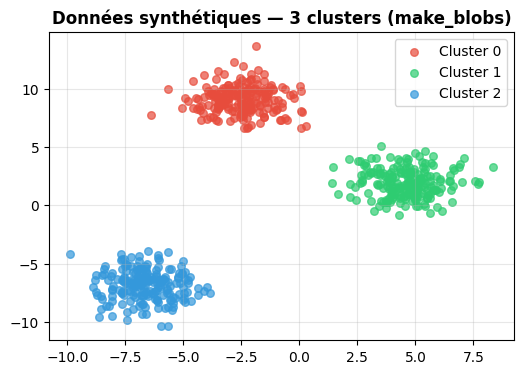

Scratch — Précision: 100.00%
Sklearn — Précision: 100.00%
Keras  — Précision: 100.00%


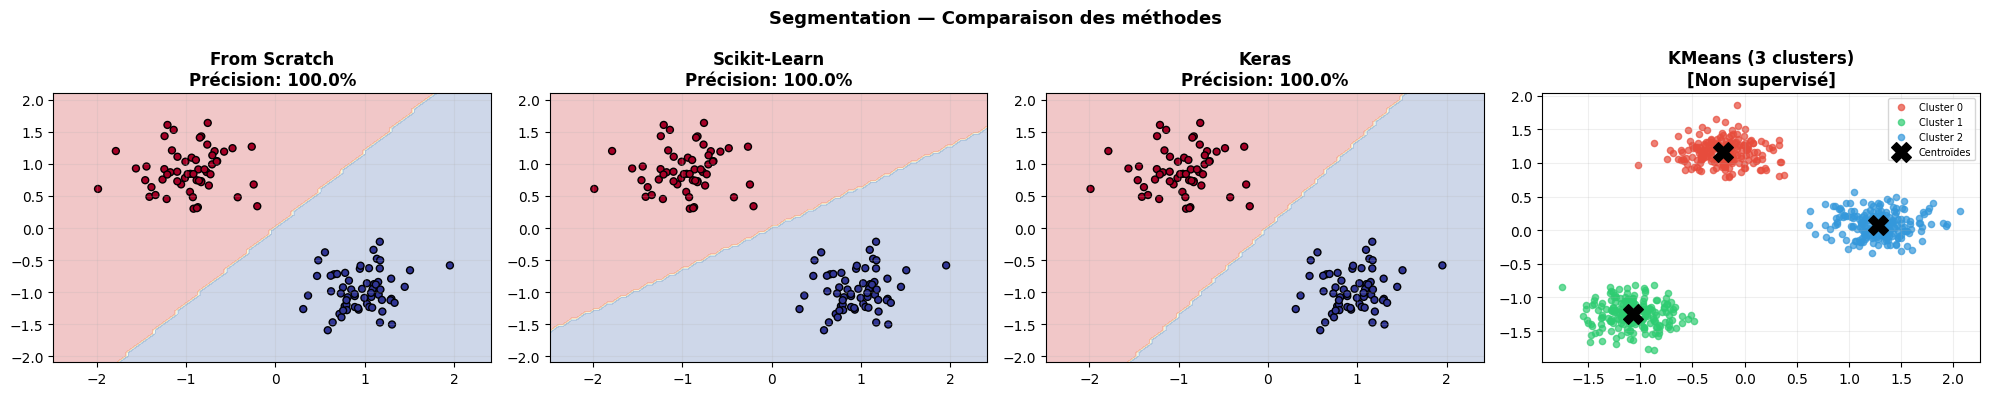


ANALYSE :
- Perceptron (supervisé) : nécessite des étiquettes. Bonne séparation binaire.
- KMeans (non supervisé) : découvre les clusters sans étiquettes.
- Les méthodes supervisées sont plus précises quand les étiquettes sont disponibles.
- KMeans est utile quand on n'a pas d'annotations.



In [13]:
# TP1 - Exercice 5 : Segmentation des données synthétiques avec le Perceptron


import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Perceptron as SklearnPerceptron
from sklearn.cluster import KMeans
from sklearn.metrics import accuracy_score
import tensorflow as tf
from tensorflow import keras

# 1. Génération des données

X_full, y_full = make_blobs(n_samples=600, centers=3, cluster_std=1.2, random_state=42)

# Visualisation initiale
plt.figure(figsize=(6, 4))
colors = ['#e74c3c', '#2ecc71', '#3498db']
for i in range(3):
    plt.scatter(X_full[y_full == i, 0], X_full[y_full == i, 1],
                c=colors[i], label=f"Cluster {i}", s=30, alpha=0.7)
plt.title("Données synthétiques — 3 clusters (make_blobs)", fontweight='bold')
plt.legend(); plt.grid(True, alpha=0.3)
plt.show()

# 2. Prétraitement (binaire : clusters 0 et 1 seulement)

mask = y_full != 2
X_bin = X_full[mask]
y_bin = y_full[mask]

scaler = StandardScaler()
X_bin_sc = scaler.fit_transform(X_bin)

X_train, X_test, y_train, y_test = train_test_split(
    X_bin_sc, y_bin, test_size=0.3, random_state=42)

# 3a. FROM SCRATCH

class PerceptronScratch:
    def __init__(self, lr=0.01, n_iter=200):
        self.lr = lr
        self.n_iter = n_iter

    def fit(self, X, y):
        self.w = np.zeros(X.shape[1])
        self.b = 0.0
        for _ in range(self.n_iter):
            for xi, yi in zip(X, y):
                yhat = self._step(np.dot(xi, self.w) + self.b)
                delta = self.lr * (yi - yhat)
                self.w += delta * xi
                self.b += delta
        return self

    def _step(self, z): return 1 if z >= 0 else 0

    def predict(self, X):
        return np.array([self._step(np.dot(xi, self.w) + self.b) for xi in X])

p_scratch = PerceptronScratch()
p_scratch.fit(X_train, y_train)
acc_scratch = accuracy_score(y_test, p_scratch.predict(X_test))
print(f"Scratch — Précision: {acc_scratch*100:.2f}%")

# 3b. SCIKIT-LEARN

clf_sk = SklearnPerceptron(max_iter=500, random_state=42)
clf_sk.fit(X_train, y_train)
acc_sk = accuracy_score(y_test, clf_sk.predict(X_test))
print(f"Sklearn — Précision: {acc_sk*100:.2f}%")

# 3c. KERAS

model = keras.Sequential([
    keras.layers.Input(shape=(2,)),
    keras.layers.Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.fit(X_train, y_train, epochs=100, batch_size=16, verbose=0)
_, acc_keras = model.evaluate(X_test, y_test, verbose=0)
print(f"Keras  — Précision: {acc_keras*100:.2f}%")

# 4. KMeans (3 clusters)

X_full_sc = scaler.fit_transform(X_full)
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_full_sc)
labels_km = kmeans.labels_

# VISUALISATION — Frontières + KMeans

def plot_boundary(ax, clf_func, X, y, title, acc):
    h = 0.05
    x0_min, x0_max = X[:, 0].min()-0.5, X[:, 0].max()+0.5
    x1_min, x1_max = X[:, 1].min()-0.5, X[:, 1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                         np.arange(x1_min, x1_max, h))
    Z = clf_func(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.25, cmap=plt.cm.RdYlBu)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', s=25)
    ax.set_title(f"{title}\nPrécision: {acc*100:.1f}%", fontweight='bold')
    ax.grid(True, alpha=0.2)

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
plot_boundary(axes[0], p_scratch.predict, X_test, y_test, "From Scratch", acc_scratch)
plot_boundary(axes[1], clf_sk.predict, X_test, y_test, "Scikit-Learn", acc_sk)
plot_boundary(axes[2],
    lambda X: (model.predict(X, verbose=0) >= 0.5).astype(int).flatten(),
    X_test, y_test, "Keras", acc_keras)

# KMeans
km_colors = ['#e74c3c', '#2ecc71', '#3498db']
for i in range(3):
    axes[3].scatter(X_full_sc[labels_km == i, 0], X_full_sc[labels_km == i, 1],
                    c=km_colors[i], s=20, alpha=0.7, label=f"Cluster {i}")
axes[3].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
                c='black', marker='X', s=200, zorder=5, label='Centroïdes')
axes[3].set_title("KMeans (3 clusters)\n[Non supervisé]", fontweight='bold')
axes[3].legend(fontsize=7); axes[3].grid(True, alpha=0.2)

plt.suptitle("Segmentation — Comparaison des méthodes", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print("""
ANALYSE :
- Perceptron (supervisé) : nécessite des étiquettes. Bonne séparation binaire.
- KMeans (non supervisé) : découvre les clusters sans étiquettes.
- Les méthodes supervisées sont plus précises quand les étiquettes sont disponibles.
- KMeans est utile quand on n'a pas d'annotations.
""")